### **Vasicek Model**
It's one of the most fundamental models in quantitative finance for modeling interest rate dynamics. This stochastic model is developed on top of Orstein-Uhlenbeck simulation. The O-U form is precisely what's needed for interesst rate because rates tend to revert back to a long term mean. Let's look at the advantages and disadvantages of Vasicek.

#### **Advantages**
- Mean reversion: The model captures the real-world behavior of interest rates, which often tend to revert to a long-term average. This feature makes it more realistic compared to models that assume constant rates.
- Simplicity: Despite being mathematically grounded, the Vasicek model is relatively simple and easy to implement, making it suitable for practical applications.
 - Closed-form solution: The Vasicek model has a known analytical solution, which allows for easier analysis and computation.
The Vasicek Model also possesses some limitations:
#### **Disadvantages**
 - Negative interest rates: One significant limitation of the Vasicek model is that it allows for the possibility of negative interest rates, which is not always realistic in practice. In reality, interest rates are generally non-negative, although some recent periods have seen negative rates in certain economies.
 - Constant volatility: The model assumes a constant level of volatility over time (i.e. 
 is a fixed value), which is not an accurate representation of real financial markets, where volatility can change in response to various economic events.
 - Lack of flexibility: The Vasicek model may be too simplistic for capturing complex interest rate dynamics, particularly in markets where rates exhibit more intricate behaviors. More advanced models, such as the Cox-Ingersoll-Ross (CIR) model, address some of these limitations.

#### **Mathematical Term:**
##### $dr_t = \theta (\mu - r_t) dt + \sigma dW_t$

#### **Where:**

$r_t$: The instantaneous short-term interest rate at time. represents the initial rate at the start of the observation period.

$\theta$: The speed of mean reversion, indicating how quickly the rate reverts to the mean. A higher value of means that the interest rate will return to the average faster, while a lower value indicates a slower adjustment.

$\mu$: The long-term mean level of the interest rate. This is the central value around which the interest rate fluctuates. It represents the average level to which the interest rate is expected to revert over time.

$\sigma$: The volatility or standard deviation of interest rate changes. This parameter controls the level of randomness or uncertainty in the movement of the interest rate. Higher volatility means more unpredictable and larger fluctuations in the interest rate.

$dW_t$: A Wiener process (standard Brownian motion) that introduces randomness

#### **The model has two components:**
 - $\theta (\mu - r_t) dt$ captures the mean reverting behavior where
     - If $r_t > \mu$, the term $(\mu - r_t)$ is negative, causing $r_t$ to decrease
     - If $r_t < \mu$, the term $(\mu - r_t)$ is positive, causing $r_t$ to increase
 - $\sigma dW_t$ <- The stochastic part that introduces random fluctuations

The Vasicek model suggests that the short-term interest shocks will be pulled towards the mean interest rate $\mu$ at a rate governed by $\theta$, while still being subject to random fluctuations determined by $\sigma$. Hence, the parameter $\theta$ determines how strongly the interest rate is pulled back towards $\mu$. Larger values of $\theta$ indicate a faster reversion to the mean, while smaller values suggest a slower adjustment.

#### **Analytical Solution**
$r_t = r_0 e^{-\theta t} + \mu(1 - e^{-\theta t}) + \sigma \int_0^t e^{-\theta (t - s)} dW_s$
#### **Where:**
- $r_0 e^{-\theta t}$: The influence of the initial rate $r_0$. Becomes less relevant over time(study the formula)
- $\mu (1 - e^{-\theta t})$: Represents the long-term mean component, which gradually dominates as $t \to \infty$.(study the formula)
- $\sigma \int_0^t e^{-\theta (t - s)} dW_s$: The accumulated impact of the stochastic shocks over time.

#### **Single shot Forecasting**
$E(r_t) = r_0 e^{-\theta t} + \mu(1 - e^{-\theta t})$

$Var(r_t) = \frac{\sigma^2}{2\theta}(1 - e^{-2 \theta t})$

#### **As $t \to \infty$ meaning long run forecast**

$Var(r_\infty) = \frac{\sigma^2}{2\theta}$ demonstrates Vasicec has a stationary distribution

#### **Numerical Solution a.k.a Descretisation:**
$r_{t+\Delta t} = r_t + \theta (\mu - r_t) \Delta t + \sigma \sqrt{\Delta t} \epsilon_t$

Here, $\epsilon_t$ is a random variable drawn from a standard normal distribution (i.e., $\epsilon_t \sim \mathcal{N}(0, 1)$). This discretization allows us to iteratively compute the value of $r_t$ over time, simulating the behavior of the Vasicek Model process.

#### **Estimation of mean reversion factor $\theta$**
$r_t - r_{t-1} = \theta (\mu - r_{t-1}) + \epsilon(0, \sigma^2)$ <- OLS estimate with no intercept if we manually compute $\mu$

$r_t - r_{t-1} = \theta \mu - \theta * r_{t-1} + \epsilon(0, \sigma^2)$ <- OLS with intercept

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import statsmodels.api as sm

### Read the data

In [2]:
treasury = pd.read_csv("../../../data/TreasuryHistory.csv")
treasury.Date = pd.to_datetime(treasury.Date)
treasury.set_index("Date", inplace=True)

### We will focus on the 10 year

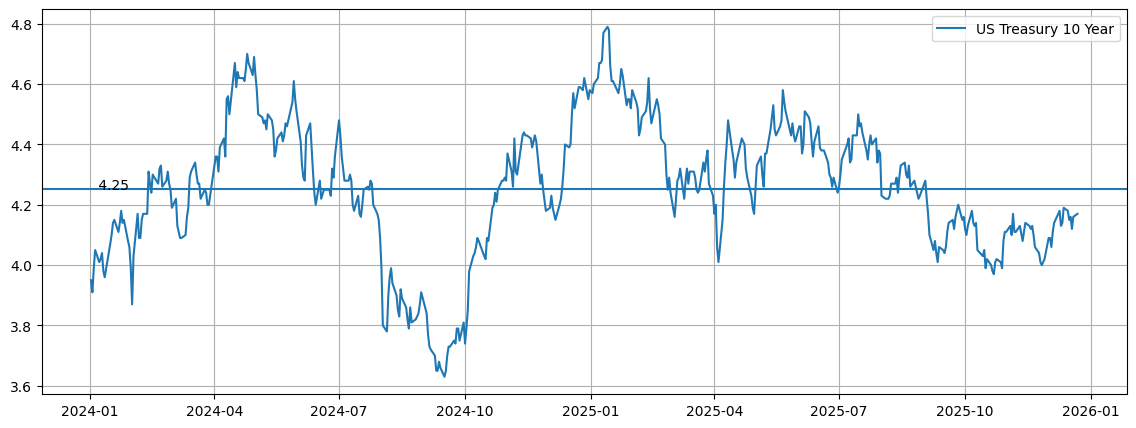

In [4]:
tenor = 'TSY10YR'
df = treasury.loc["2024":,[tenor]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df[tenor], label="US Treasury 10 Year")
ax.axhline(y = df[tenor].mean())
ax.text(x = datetime.date.fromisoformat("2024-01-04"), y = df[tenor].mean(), 
        s = f"{ df[tenor].mean() : .2f}")
ax.grid()
ax.legend()

### Estimate $\mu$ , $\sigma$ and $\theta$

- Method 1: $\mu$ and $\sigma$ estimated using frequentists methods but mean reversion coefficient will have to be estimated using OLS.
- Estimate $\mu$ , $\sigma$ and $\theta$ using OLS

### Method 1
$r_t - r_{t-1} = \theta (\mu - r_{t-1}) + \epsilon(0, \sigma^2)$ <- OLS estimate with no intercept if we manually compute $\mu$

In [5]:
temp = df.copy()
# tenor = "TSY3MO"
# temp = treasury.loc["2010":,[tenor]].copy() or
# temp = treasury[[tenor]].copy()
temp[tenor] = temp[tenor].ffill()
temp[tenor] = temp[tenor]/100
temp['diff'] = temp[tenor].diff()
temp['mu-lag1'] = temp[tenor].mean() - temp[tenor].shift()
temp.tail()

,TSY10YR,diff,mu-lag1
Date,,,
2025-12-16,0.0415,-0.0003,0.000717
2025-12-17,0.0416,0.0001,0.001017
2025-12-18,0.0412,-0.0004,0.000917
2025-12-19,0.0416,0.0004,0.001317
2025-12-22,0.0417,0.0001,0.000917


In [6]:
result = sm.OLS(temp['diff'].dropna(), temp['mu-lag1'].dropna()).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   diff   R-squared (uncentered):                   0.016
Model:                            OLS   Adj. R-squared (uncentered):              0.014
Method:                 Least Squares   F-statistic:                              8.001
Date:                Sat, 25 Apr 2026   Prob (F-statistic):                     0.00487
Time:                        03:56:02   Log-Likelihood:                          3011.3
No. Observations:                 492   AIC:                                     -6021.
Df Residuals:                     491   BIC:                                     -6016.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
mu-lag1        0.0303      0.011      2.829      0.005       0.009       0.051
==============================================================================
Omnibus:                        8.344   Durbin-Watson:                   1.871
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                9.309
Skew:                           0.225   Prob(JB):                      0.00952
Kurtosis:                       3.501   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
mu = temp[tenor].mean()
sigma = temp[tenor].std()
theta = result.params['mu-lag1']
print(f"Mu : {mu : .4f} | Sigma: {sigma: .4f} | Theta: {theta : .4f}")

Mu :  0.0425 | Sigma:  0.0022 | Theta:  0.0303


### Method 2
$r_t - r_{t-1} = \theta \mu - \theta * r_{t-1} + \epsilon(0, \sigma^2)$ <- OLS with intercept

In [8]:
temp = df.copy()
# tenor = "TSY3MO"
# temp = treasury.loc["2024":,[tenor]].copy() #or
# temp = treasury[[tenor]].copy()
temp[tenor] = temp[tenor].ffill()
temp[tenor] = temp[tenor]/100
temp['diff'] = temp[tenor].diff()
temp['lag1'] = temp[tenor].shift()
temp.tail()

,TSY10YR,diff,lag1
Date,,,
2025-12-16,0.0415,-0.0003,0.0418
2025-12-17,0.0416,0.0001,0.0415
2025-12-18,0.0412,-0.0004,0.0416
2025-12-19,0.0416,0.0004,0.0412
2025-12-22,0.0417,0.0001,0.0416


In [9]:
result = sm.OLS(temp['diff'].dropna(), sm.add_constant(temp['lag1'].dropna())).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   diff   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     7.986
Date:                Sat, 25 Apr 2026   Prob (F-statistic):            0.00491
Time:                        03:56:28   Log-Likelihood:                 3011.3
No. Observations:                 492   AIC:                            -6019.
Df Residuals:                     490   BIC:                            -6010.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.000      2.832      0.005       0.000       0.002
lag1          -0.0303      0.011     -2.826      0.005      -0.051      -0.009
==============================================================================
Omnibus:                        8.344   Durbin-Watson:                   1.872
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                9.309
Skew:                           0.225   Prob(JB):                      0.00952
Kurtosis:                       3.501   Cond. No.                         447.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
theta_times_mu = intercept = result.params['const']
theta = -result.params['lag1']
mu = theta_times_mu/theta
sigma = temp[tenor].std() #Because Vasicek Model assumes constant variance 
print(f"Mu : {mu : .4f} | Sigma: {sigma: .4f} | Theta: {theta : .4f}")

Mu :  0.0427 | Sigma:  0.0022 | Theta:  0.0303


### Notice Method 2 Mu slightly greater than Method 1 Mu. Perhaps it's due to one less data point in the past
<p style="color:tomato">Even though this is a nifty trick but it's not piratical . For example with this method if we estimate mu, and theta for TSY3MO using data from 2020 to 2024 we get long run mu of 7.9% which is definitely not the usual exception for a short term rate unless we are in a extreme inflationary period.</p>

### Simulation Forecast

In [11]:
def vasicek_model(theta, mu, sigma, r0, T, dt):
    """
    Simulate the Vasicek model using the Euler-Maruyama method.

    Parameters
    ----------
    theta : `float`
        The speed of mean reversion
    mu : `float`
        The long-term mean level
    sigma : `float`
        The volatility of the random aspect
    r0 : `float`
        The initial interest rate
    T : `float`
        The total time horizon
    dt : `float`
        The time step size

    Returns
    -------
    `np.ndarray`
        The array of simulated interest rates over time
    """
    N = int(T / dt)  # Number of time steps
    rates = np.zeros(N)  # Pre-allocate an array large enough for the sample path
    rates[0] = r0  # Set the initial rate

    for t in range(1, N):  # Skip the initial rate (start at 1, not 0)
        dr = theta * (mu - rates[t - 1]) * dt + sigma * np.sqrt(dt) * np.random.normal()
        rates[t] = rates[t - 1] + dr
    return rates

def simulate_vasicek_paths(theta, mu, sigma, r0, T, dt, num_simulations):
    """
    Simulate multiple interest rate paths using the Vasicek model.

    Parameters
    ----------
    theta : `float`
        The speed of mean reversion
    mu : `float`
        The long-term mean level
    sigma : `float`
        The volatility of the random aspect
    r0 : `float`
        The initial interest rate
    T : `float`
        The total time horizon
    dt : `float`
        The time step size
    num_simulations : `int`
        The number of Monte Carlo simulations to run

    Returns
    -------
    `pd.DataFrame`
        The Pandas DataFrame containing simulated interest rate paths
    """
    N = int(T / dt)  # Number of time steps
    all_simulations = np.zeros((N, num_simulations))  # Pre-allocate the two-dimensional array of multiple paths
    
    for i in range(num_simulations):
        all_simulations[:, i] = vasicek_model(theta, mu, sigma, r0, T, dt)
    
    return pd.DataFrame(
        all_simulations,
        columns=[f'Simulation {i+1}' for i in range(num_simulations)]
    )

## Run the two functions below
r0 = df[tenor].iloc[-1]/100  # Last Value as the initial value
T = 1.0  # Time horizon (1 year)
dt = 1/252  # Time step size
num_simulations = 10  # Number of sample paths to generate

# Simulate the paths
simulated_paths = simulate_vasicek_paths(theta, mu, sigma, r0, T, dt, num_simulations)

<Axes: >

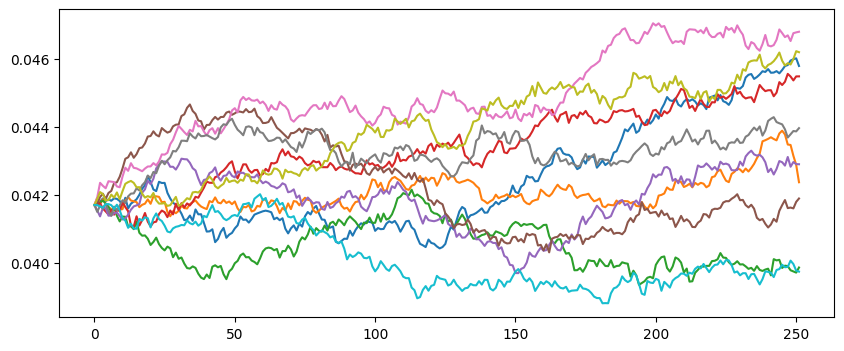

In [12]:
simulated_paths.plot(legend=False, figsize=(10,4))

In [13]:
simulated_paths.shape

(252, 10)

### Disdvantages¶

- **Negative interest rates**: One significant limitation of the Vasicek model is that it allows for the possibility of negative interest rates, which is not always realistic in practice. In reality, interest rates are generally non-negative, although some recent periods have seen negative rates in certain economies.

- **Constant volatility**: The model assumes a constant level of volatility over time (i.e. is a fixed value), which is not an accurate representation of real financial markets, where volatility can change in response to various economic events.

- **Lack of flexibility**: The Vasicek model may be too simplistic for capturing complex interest rate dynamics, particularly in markets where rates exhibit more intricate behaviors. More advanced models, such as the Cox-Ingersoll-Ross (CIR) model, address some of these limitations.
